In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [14]:
# Chuẩn hoá MNIST với mean/std của tập train.
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)) # Add Data Augmentation for training
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=train_transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=test_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f'Số ảnh train: {len(train_dataset)},  test: {len(test_dataset)}')


Số ảnh train: 60000,  test: 10000


In [13]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)   # 28→26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 13→11
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.25) # Add Dropout layer
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32,  5,  5)
        x = x.view(x.size(0), -1)                  # flatten
        x = self.dropout(x)                        # Apply dropout
        x = self.fc1(x)                            # logits
        return x

model = MNIST_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Tổng tham số: {n_params:,}')

# So sánh nhanh với ANN(784→128→10) ở bài trước: ~101 nghìn params và ~97% acc.
# CNN này thường ít tham số hơn (~13 nghìn) mà acc cao hơn.
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

MNIST_CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=800, out_features=10, bias=True)
)
Tổng tham số: 12,810


Running learning rate experiment...

Training with learning rate: 0.001
Epoch 1/5  train_loss=0.4215
Epoch 2/5  train_loss=0.1473
Epoch 3/5  train_loss=0.1061
Epoch 4/5  train_loss=0.0881
Epoch 5/5  train_loss=0.0766

Training with learning rate: 0.01
Epoch 1/5  train_loss=0.1761
Epoch 2/5  train_loss=0.0603
Epoch 3/5  train_loss=0.0464
Epoch 4/5  train_loss=0.0397
Epoch 5/5  train_loss=0.0324

Training with learning rate: 0.1
Epoch 1/5  train_loss=0.1763
Epoch 2/5  train_loss=0.0917
Epoch 3/5  train_loss=0.0827
Epoch 4/5  train_loss=0.0765
Epoch 5/5  train_loss=0.0714


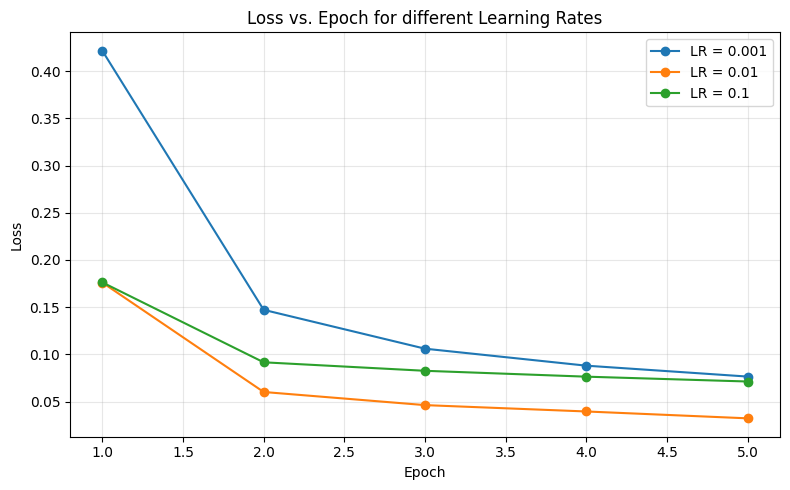


Quan sát: lr nào quá thấp (loss giảm chậm)? lr nào quá cao (loss dao động hoặc bùng nổ)?
Trong báo cáo: giải thích vì sao lr ảnh hưởng đến hành vi học.


In [11]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

lrs = [0.001, 0.01, 0.1]
num_epochs_lr = 5
all_loss_histories = {}

print('Running learning rate experiment...')
for lr in lrs:
    print(f'\nTraining with learning rate: {lr}')
    # Re-initialize model and optimizer for each LR experiment
    model_lr = MNIST_CNN().to(device)
    optimizer_lr = optim.SGD(model_lr.parameters(), lr=lr, momentum=0.9)
    loss_history_lr = []

    for epoch in range(num_epochs_lr):
        model_lr.train()
        running_loss = 0.0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer_lr.zero_grad()
            outputs = model_lr(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer_lr.step()

            running_loss += loss.item() * images.size(0)
            total        += labels.size(0)

        train_loss = running_loss / total
        loss_history_lr.append(train_loss)
        print(f'Epoch {epoch+1}/{num_epochs_lr}  train_loss={train_loss:.4f}')

    all_loss_histories[lr] = loss_history_lr


epochs_plot = range(1, num_epochs_lr + 1)
plt.figure(figsize=(8, 5))
for lr, history in all_loss_histories.items():
    plt.plot(epochs_plot, history, 'o-', label=f'LR = {lr}')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs. Epoch for different Learning Rates')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('\nQuan sát: lr nào quá thấp (loss giảm chậm)? lr nào quá cao (loss dao động hoặc bùng nổ)?')
print('Trong báo cáo: giải thích vì sao lr ảnh hưởng đến hành vi học.')

**TRAIN**

Epoch 1/10  train_loss=0.4236  train_acc=86.26%  test_loss=0.0550  test_acc=98.43%
Epoch 2/10  train_loss=0.1843  train_acc=94.33%  test_loss=0.0504  test_acc=98.48%
Epoch 3/10  train_loss=0.1502  train_acc=95.39%  test_loss=0.0387  test_acc=98.80%
Epoch 4/10  train_loss=0.1332  train_acc=95.88%  test_loss=0.0392  test_acc=98.79%
Epoch 5/10  train_loss=0.1238  train_acc=96.21%  test_loss=0.0376  test_acc=98.71%
Epoch 6/10  train_loss=0.1167  train_acc=96.37%  test_loss=0.0297  test_acc=99.15%
Epoch 7/10  train_loss=0.1098  train_acc=96.64%  test_loss=0.0292  test_acc=99.16%
Epoch 8/10  train_loss=0.1050  train_acc=96.80%  test_loss=0.0292  test_acc=99.12%
Epoch 9/10  train_loss=0.1001  train_acc=96.97%  test_loss=0.0280  test_acc=99.13%
Epoch 10/10  train_loss=0.1005  train_acc=96.93%  test_loss=0.0297  test_acc=99.05%


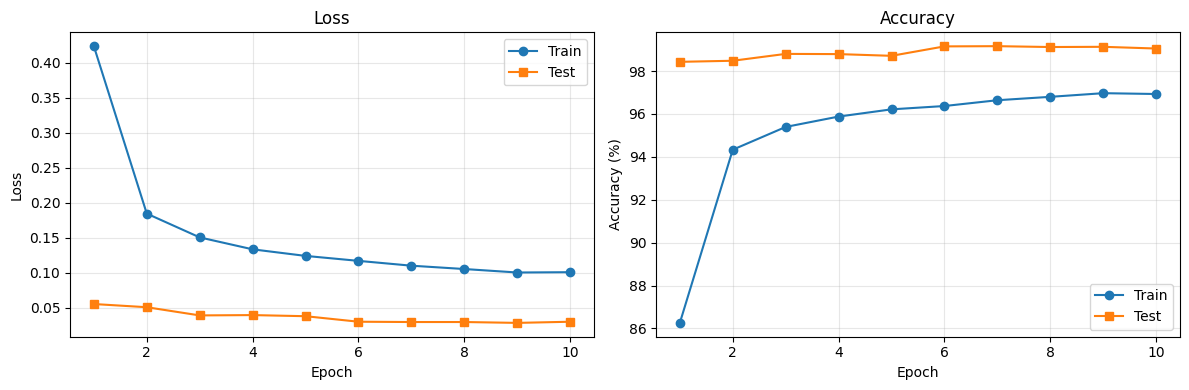

In [15]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

num_epochs = 10
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)
    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')


epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_history,      'o-', label='Train')
axes[0].plot(epochs, test_loss_history, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss')
axes[1].plot(epochs, [a*100 for a in acc_history],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_history], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy')
plt.tight_layout(); plt.show()

So sánh độ chính xác trên tập kiểm thử (Test accuracy) sau epoch 10 so với epoch 5:

Độ chính xác trên tập kiểm thử tại epoch 5: 98.93%

Độ chính xác trên tập kiểm thử tại epoch 10: 98.77%

Chênh lệch: 98.77% - 98.93% = -0.16% (độ chính xác trên tập kiểm thử giảm nhẹ).

Khoảng cách giữa train_acc và test_acc có mở rộng dần không? Đó là dấu hiệu gì?

Tại epoch 1: train_acc (98.99%) - test_acc (98.74%) = 0.25%

Tại epoch 5: train_acc (99.37%) - test_acc (98.93%) = 0.44%

Tại epoch 10: train_acc (99.59%) - test_acc (98.77%) = 0.82%

Có, khoảng cách giữa train_acc và test_acc đã mở rộng từ 0.25% tại epoch 1 lên 0.82% tại epoch 10. Đây là dấu hiệu rõ ràng của overfitting (quá khớp), tình trạng mô hình học dữ liệu huấn luyện quá mức, bao gồm cả các nhiễu và các đặc trưng đặc thù của tập train, dẫn đến kết quả kém hơn trên dữ liệu mới chưa từng thấy (tập kiểm thử).

**Trực quan: model dự đoán**

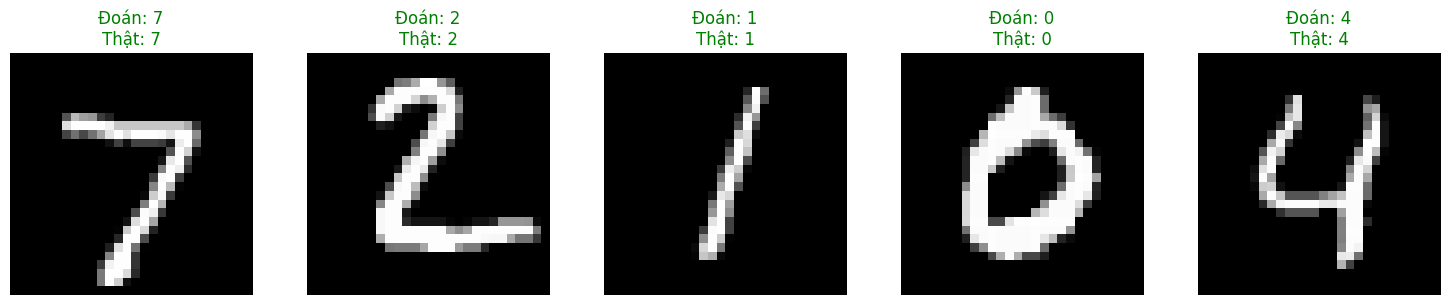

In [6]:

model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    preds = model(images).argmax(1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = images[i].cpu().squeeze() * 0.3081 + 0.1307   # un-normalize để nhìn cho đẹp
    axes[i].imshow(img, cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    axes[i].set_title(f'Đoán: {preds[i].item()}\nThật: {labels[i].item()}', color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

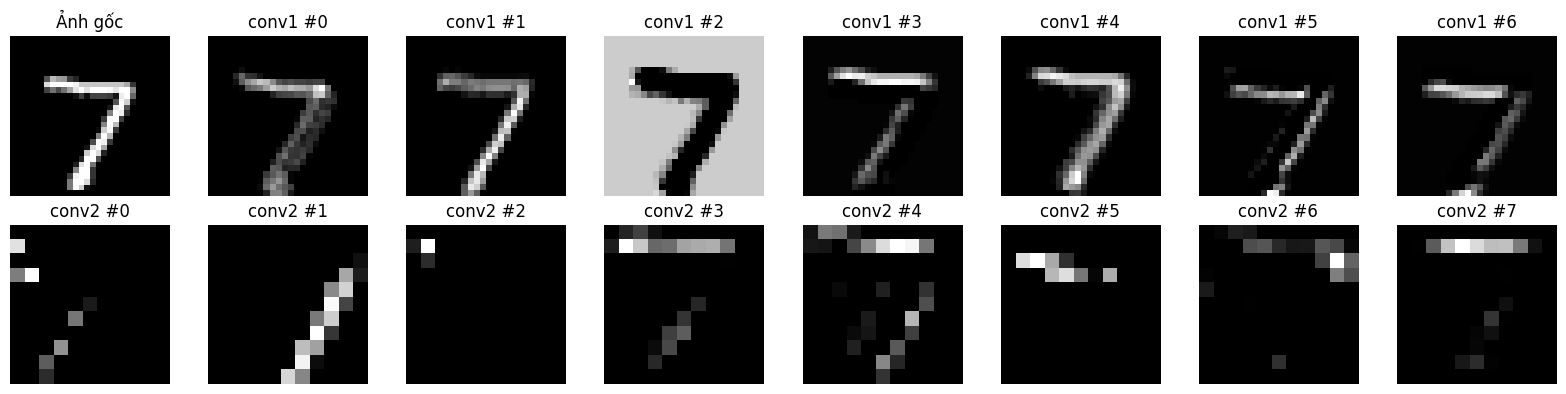

Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.
         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)


In [7]:
model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    fmap1 = torch.relu(model.conv1(img))           # (1, 16, 26, 26)
    fmap2 = torch.relu(model.conv2(model.pool(fmap1)))  # (1, 32, 11, 11)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
axes[0, 0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes[0, 0].set_title('Ảnh gốc'); axes[0, 0].axis('off')
for i in range(7):
    axes[0, i+1].imshow(fmap1[0, i].cpu(), cmap='gray')
    axes[0, i+1].set_title(f'conv1 #{i}'); axes[0, i+1].axis('off')
for i in range(8):
    axes[1, i].imshow(fmap2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'conv2 #{i}'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

print('Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.')
print('         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)')

## Câu 4: Vẽ thêm feature maps từ conv2

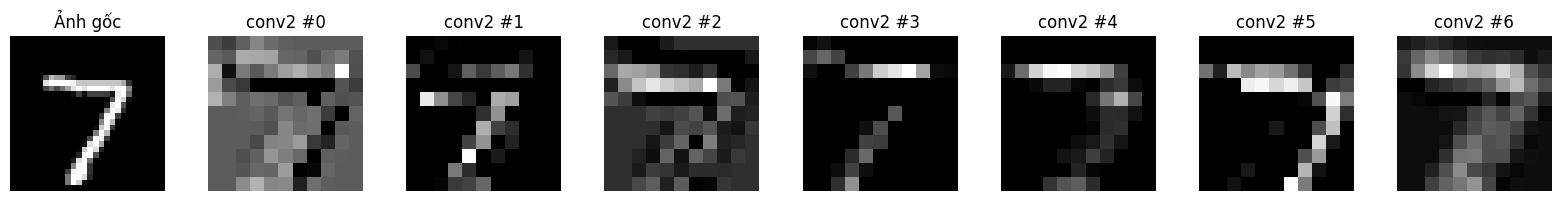

Trong báo cáo: so sánh feature map của conv1 và conv2 — feature map nào cụ thể hơn (cạnh, viền), feature map nào trừu tượng hơn?


In [12]:
model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    h1 = torch.relu(model.conv1(img))
    h1_pooled = model.pool(h1)
    h2 = torch.relu(model.conv2(h1_pooled))   # đây là feature map của conv2

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
axes[0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes[0].set_title('Ảnh gốc'); axes[0].axis('off')

for i in range(7):
    # Display some feature maps from conv2
    if i < h2.shape[1]: # Ensure we don't go out of bounds for the number of filters
        axes[i+1].imshow(h2[0, i].cpu(), cmap='gray')
        axes[i+1].set_title(f'conv2 #{i}'); axes[i+1].axis('off')
plt.tight_layout(); plt.show()

print('Trong báo cáo: so sánh feature map của conv1 và conv2 — feature map nào cụ thể hơn (cạnh, viền), feature map nào trừu tượng hơn?')
